# Notebook 13 – EDA Report

### Dataset creation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Age": [22, 25, 28, 30, 32, 35, 38, 40, 42, 45, 48, 50, 52, 55, 58],
    "Salary": [30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000, 100000],
    "Department": ["IT", "HR", "IT", "Finance", "HR", "IT", "Finance", "IT", "HR", "Finance", "IT", "HR", "Finance", "IT", "Finance"],
    "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
}

df = pd.DataFrame(data)

df.head()

,Age,Salary,Department,Experience
0,22,30000,IT,1
1,25,35000,HR,2
2,28,40000,IT,3
3,30,45000,Finance,4
4,32,50000,HR,5


# 1. Dataset Overview

## Dataset Source

The dataset used in this notebook is a small employee dataset created for EDA practice.

## Domain

The dataset belongs to the Human Resources / Employee Analytics domain.

## Features

The dataset contains the following features:

- Age
- Salary
- Department
- Experience

## Target

No target variable has been defined because this notebook focuses on Exploratory Data Analysis rather than building a machine learning model.

## Dataset Size

The dataset contains 15 observations and 4 features.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFeatures:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Number of rows: 15
Number of columns: 4

Features:
['Age', 'Salary', 'Department', 'Experience']

Data types:
Age            int64
Salary         int64
Department    object
Experience     int64
dtype: object

First 5 rows:


,Age,Salary,Department,Experience
0,22,30000,IT,1
1,25,35000,HR,2
2,28,40000,IT,3
3,30,45000,Finance,4
4,32,50000,HR,5


# 2. Data Quality

Data quality analysis is performed to identify problems that may affect future analysis or machine learning.

The main areas checked are:

- Missing values
- Duplicates
- Invalid values
- Data-type issues

## 2.1 Missing Values

Missing values are checked to determine whether any observations are incomplete.

Identifying missing values is important because they may affect statistical calculations and machine learning models.

In [3]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Age           0
Salary        0
Department    0
Experience    0
dtype: int64


### Finding

The dataset does not contain missing values.

Therefore, no missing-value treatment is required for the current dataset.

In a larger real-world dataset, missing values would need to be investigated and an appropriate treatment strategy would be selected during preprocessing.

## 2.2 Duplicates

Duplicate rows are checked to determine whether the same observation appears more than once.

Duplicates can affect statistical analysis by giving repeated observations more influence.

In [4]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Finding

The dataset does not contain duplicate rows.

Therefore, no duplicate removal is required at this stage.

## 2.3 Invalid Values

Numerical values are checked against basic logical conditions.

For example:

- Age should be positive.
- Salary should be positive.
- Experience should not be negative.

In [5]:
print("Invalid Age values:")
print(df[df["Age"] <= 0])

print("\nInvalid Salary values:")
print(df[df["Salary"] <= 0])

print("\nInvalid Experience values:")
print(df[df["Experience"] < 0])

Invalid Age values:
Empty DataFrame
Columns: [Age, Salary, Department, Experience]
Index: []

Invalid Salary values:
Empty DataFrame
Columns: [Age, Salary, Department, Experience]
Index: []

Invalid Experience values:
Empty DataFrame
Columns: [Age, Salary, Department, Experience]
Index: []


### Finding

No invalid Age, Salary, or Experience values were identified based on the basic logical checks.

The values appear reasonable for the purpose of this practice dataset.

## 2.4 Data-Type Issues

Data types are checked to make sure numerical variables are stored as numerical data and categorical variables are stored appropriately.

Incorrect data types can cause problems during statistical analysis and machine learning.

In [6]:
print(df.dtypes)

Age            int64
Salary         int64
Department    object
Experience     int64
dtype: object


### Finding

Age, Salary, and Experience are stored as numerical variables.

Department is stored as a categorical/text variable.

No obvious data-type issue was identified in the current dataset.

# 3. Statistical Findings

Statistical analysis is used to understand the center, spread, distribution, and unusual values in the dataset.

The following areas are examined:

- Central tendency
- Dispersion
- Distribution
- Outliers

## 3.1 Central Tendency

Mean and median are used to understand the typical values of the numerical variables.

The mean represents the average value, while the median represents the middle value after sorting the observations.

In [7]:
numerical_columns = ["Age", "Salary", "Experience"]

central_tendency = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median()
})

print(central_tendency)

               Mean   Median
Age            40.0     40.0
Salary      65000.0  65000.0
Experience      8.0      8.0


### Finding

The mean and median values provide an estimate of the typical Age, Salary, and Experience in the dataset.

Comparing the mean and median also helps identify whether the variables may be affected by extreme values.

## 3.2 Dispersion

Dispersion describes how widely the observations are spread around their central values.

Standard deviation is used here to measure the spread of the numerical variables.

In [8]:
dispersion = pd.DataFrame({
    "Variance": df[numerical_columns].var(),
    "Standard Deviation": df[numerical_columns].std(),
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max()
})

print(dispersion)

                Variance  Standard Deviation  Minimum  Maximum
Age         1.265714e+02           11.250397       22       58
Salary      5.000000e+08        22360.679775    30000   100000
Experience  2.000000e+01            4.472136        1       15


### Finding

Salary has a wide numerical range compared with Age and Experience.

The standard deviation provides additional information about how spread out the observations are within each numerical variable.

## 3.3 Distribution

The distribution of numerical variables is examined using histograms.

Understanding the distribution helps identify concentration, spread, and possible skewness in the data.

In [ ]:
df[numerical_columns].hist(figsize=(10, 6), bins=6)

plt.suptitle("Distribution of Numerical Variables")
plt.show()

### Finding

The distributions show how Age, Salary, and Experience are spread across the observations.

The small size of the dataset should be considered when interpreting the shape of these distributions.

## 3.4 Outliers

Outliers are observations that are unusually far from the rest of the data.

The IQR method is used to identify potential outliers in the numerical variables.

In [10]:
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(f"{column}:")
    print("Number of potential outliers:", len(outliers))
    print()

Age:
Number of potential outliers: 0

Salary:
Number of potential outliers: 0

Experience:
Number of potential outliers: 0



### Finding

The IQR method is used to identify potential outliers.

Any detected outlier should not automatically be removed. It should first be investigated to determine whether it represents a genuine observation or a data-quality problem.

Outlier treatment will be considered during the preprocessing sprint.

# 4. Relationship Findings

Relationships between variables are examined to understand how features interact with each other.

The main areas examined are:

- Correlations
- Feature relationships
- Important patterns

## 4.1 Correlations

Correlation is used to measure the strength and direction of the relationship between numerical variables.

A positive correlation means that two variables tend to increase together, while a negative correlation means that one tends to decrease as the other increases.

In [11]:
correlation_matrix = df[numerical_columns].corr()

print(correlation_matrix)

                 Age    Salary  Experience
Age         1.000000  0.999452    0.999452
Salary      0.999452  1.000000    1.000000
Experience  0.999452  1.000000    1.000000


## 4.2 Feature Relationships

The relationship between Experience and Salary is examined because both are numerical variables and may be related to employee compensation.

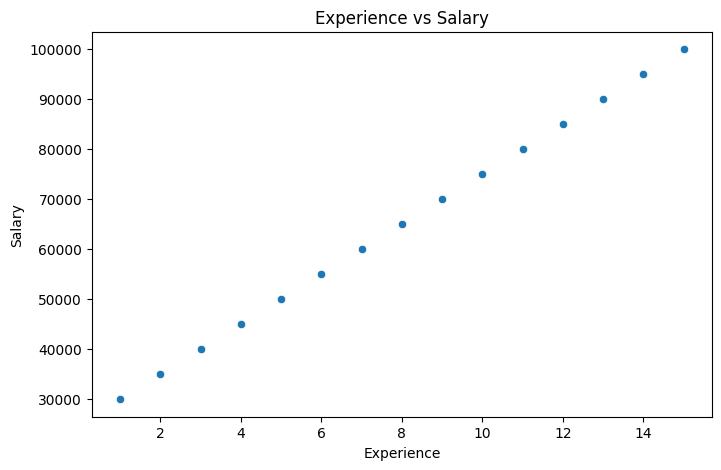

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Experience",
    y="Salary"
)

plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary")

plt.show()

### Finding

The scatter plot shows a positive relationship between Experience and Salary.

As experience increases, salary generally increases in this dataset.

## 4.3 Important Patterns

### Pattern 1

Salary generally increases with Experience.

### Pattern 2

Employees belong to different departments, allowing department-level comparisons.

### Pattern 3

Age and Experience also increase together in this practice dataset.

These patterns may be useful for further analysis and feature engineering in a future sprint.

# 5. Visualization Findings

The visualizations from the EDA help communicate important patterns in the dataset.

The most important findings are:

- The salary histogram shows the spread of employee salaries.
- The box plot helps identify potential salary outliers.
- The department bar chart allows comparison of average salary between departments.
- The count plot shows the number of employees in each department.
- The scatter plot shows a positive relationship between Experience and Salary.
- The line plot shows an increasing salary trend with Experience.
- The violin plot allows salary distributions to be compared across departments.
- The pair plot shows relationships between multiple numerical variables.
- The heatmap makes correlations between numerical variables easier to identify.
- The distribution plot shows the overall shape of the Salary distribution.

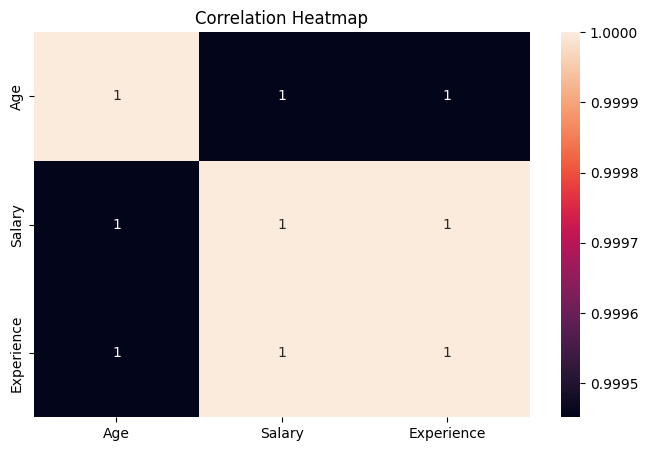

In [13]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

### Main Visualization Insight

The most important relationship visible in the visualizations is the positive relationship between Experience and Salary.

This suggests that employee experience is strongly associated with salary in this dataset.

The visualizations also help identify department-level differences and potential unusual observations.

# 6. Potential Data Problems

The EDA identified the following areas that may need attention during the preprocessing sprint:

1. Outliers should be investigated before deciding whether they should be removed or retained.

2. Department is a categorical feature and may require encoding before being used in a machine learning model.

3. Numerical features may require scaling depending on the machine learning algorithm used.

4. The dataset is very small, so conclusions should be treated carefully.

5. Feature relationships should be considered before selecting features for a machine learning model.

These problems are documented here but are not fully treated in this notebook.

# 7. Recommendations

Based on the EDA findings, the following actions can be considered during the next preprocessing sprint:

### Missing Values

No missing values were identified, so no missing-value treatment is currently required.

### Outlier Treatment

Investigate potential outliers and decide whether they are valid observations or data-quality problems.

### Encoding

Encode the Department feature before using it in a machine learning model.

### Scaling

Consider scaling numerical features if the selected machine learning algorithm is sensitive to feature scale.

### Feature Transformation

Consider transformations only if future analysis shows that a numerical feature has a highly skewed distribution.

### Feature Engineering

Experience and Age may be used to create additional meaningful features if required by the future machine learning problem.

### Data Type Correction

No major data-type problems were identified in the current dataset.

# 8. Final EDA Summary

## Dataset Overview

The dataset contains 15 observations and 4 features: Age, Salary, Department, and Experience.

The domain is Human Resources / Employee Analytics.

No target variable has been defined because the current work focuses on EDA.

## Data Quality

No missing values or duplicate rows were found.

The basic validity checks did not identify invalid Age, Salary, or Experience values.

No obvious data-type issues were identified.

## Statistical Findings

Central tendency was examined using mean and median.

Dispersion was examined using variance, standard deviation, minimum, and maximum values.

The distributions of the numerical variables were examined using histograms.

Potential outliers were checked using the IQR method.

## Relationship Findings

Experience and Salary show a positive relationship.

The correlation matrix helps identify relationships between numerical features.

## Visualization Findings

The visualizations provide evidence of salary trends, department differences, numerical distributions, and relationships between features.

## Potential Data Problems

Potential outliers and categorical encoding should be considered during preprocessing.

Feature scaling may also be required depending on the machine learning algorithm.

## Recommendations

The next sprint should focus on preprocessing the identified issues rather than repeating the EDA.

Possible preprocessing tasks include:

- Outlier treatment
- Encoding
- Scaling
- Feature transformation
- Feature engineering
- Data validation

No complete preprocessing has been performed in this notebook.

# Conclusion

EDA helped us understand the structure, quality, distribution, and relationships within the dataset.

The main finding is that Experience has a strong positive relationship with Salary.

The dataset currently has no missing values, duplicate rows, or obvious invalid values. However, potential outliers and categorical features should be considered during preprocessing.

The purpose of this notebook was to identify and document these issues.

The actual preprocessing will be performed in the next sprint.